In [ ]:
"""
RAND HRS Persona Development — 50+ US Population
Three personas clustered on Health, Lifestyle/Engagement, and Age/Life Stage.

Run top-to-bottom or section by section in a Jupyter notebook.
Adjust FILEPATH and WAVE to match your downloaded file.
"""

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
# ============================================================
# CONFIG
# ============================================================
FILEPATH = "/content/drive/MyDrive/AARP - Consulting /randhrs1992_2022v1.dta"   # path to your downloaded RAND HRS file
WAVE = 15                              # 15 = 2020 (final release, safest)
                                       # 16 = 2022 (early release; some vars TBD)
OUTPUT_DIR = "."


In [ ]:

# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_stata(FILEPATH, convert_categoricals=False)
df.columns = df.columns.str.lower()
print(f"Loaded: {df.shape[0]:,} respondents × {df.shape[1]:,} variables")

Loaded: 45,234 respondents × 19,880 variables


In [ ]:
# Quick diagnostic: find ADL/IADL/cognition vars for wave 15
w = 15
patterns = {
    "ADL":       [f"r{w}adl", f"r{w}adltot"],
    "IADL":      [f"r{w}iadl", f"r{w}iadltot"],
    "Cognition": [f"r{w}cog", f"r{w}tr20", f"r{w}imrc", f"r{w}dlrc"],
}
for label, prefixes in patterns.items():
    matches = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]
    print(f"\n{label}: {matches}")


ADL: ['r15adl5a', 'r15adl5h', 'r15adl6a', 'r15adl6h']

IADL: ['r15iadl5a', 'r15iadl5h']

Cognition: ['r15imrcp', 'r15imrcw', 'r15dlrcp', 'r15dlrcw', 'r15tr20p', 'r15tr20w', 'r15cogtotp', 'r15cog27', 'r15cogmode']


In [ ]:
# ============================================================
# 2. VARIABLE SELECTION
#   Note: if a variable name fails, check the codebook — RAND HRS
#   occasionally renames between waves (e.g. vgactx vs vigact).
# ============================================================
w = WAVE

vars_health = [
    f"r{w}conde",
    f"r{w}shlt",
    f"r{w}adl5a",     # was r15adla
    f"r{w}iadl5a",    # was r15iadla
    f"r{w}cog27",     # was r15cogtot
    f"r{w}bmi",
]

vars_lifestyle = [
    f"r{w}vgactx",    # vigorous activity frequency (lower = more frequent)
    f"r{w}mdactx",    # moderate activity frequency
    f"r{w}lbrf",      # labor force status
    f"r{w}sayret",    # self-reported retirement (0=not retired, 1=partly, 2=fully)
]

vars_demo = [
    f"r{w}agey_e",    # age at interview, years
    "ragender",       # 1=male, 2=female
    "raracem",        # race
    "raedyrs",        # years of education
    f"h{w}itot",      # household total income
    f"r{w}iwstat",    # interview status (1 = alive, interviewed)
]

all_vars = vars_health + vars_lifestyle + vars_demo
df_w = df[all_vars].copy()

# Filter: alive respondents in this wave, age 50+
df_w = df_w[df_w[f"r{w}iwstat"] == 1]
df_w = df_w[df_w[f"r{w}agey_e"] >= 50]
print(f"After filtering (alive, 50+): {len(df_w):,} respondents")

After filtering (alive, 50+): 15,412 respondents


In [ ]:
# ============================================================
# 3. DATA EXPLORATION
# ============================================================
print("\n--- Missingness (% of rows) ---")
miss = df_w.isna().mean().mul(100).round(1).sort_values(ascending=False)
print(miss[miss > 0])

print("\n--- Numeric summary ---")
print(df_w.describe().round(2).T)

# Distributions
numeric_cols = df_w.select_dtypes(include=np.number).columns
n = min(len(numeric_cols), 12)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, col in enumerate(numeric_cols[:n]):
    df_w[col].hist(ax=axes.flatten()[i], bins=30)
    axes.flatten()[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hrs_distributions.png", dpi=120)
plt.close()

# Correlation heatmap (clustering inputs only)
corr_vars = vars_health + vars_lifestyle + [f"r{w}agey_e"]
plt.figure(figsize=(10, 8))
sns.heatmap(df_w[corr_vars].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Correlation: clustering inputs")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hrs_correlations.png", dpi=120)
plt.close()

print(f"\nSaved exploration plots to {OUTPUT_DIR}/")



--- Missingness (% of rows) ---
r15cog27     4.6
r15sayret    2.9
r15bmi       1.4
r15vgactx    0.7
r15adl5a     0.5
r15iadl5a    0.5
raracem      0.4
r15mdactx    0.4
raedyrs      0.4
r15shlt      0.1
dtype: float64

--- Numeric summary ---
             count      mean        std   min      25%       50%      75%  \
r15conde   15412.0      2.41       1.56   0.0      1.0      2.00      3.0   
r15shlt    15393.0      2.92       1.02   1.0      2.0      3.00      4.0   
r15adl5a   15338.0      0.38       0.98   0.0      0.0      0.00      0.0   
r15iadl5a  15336.0      0.33       0.93   0.0      0.0      0.00      0.0   
r15cog27   14697.0     15.47       4.70   0.0     12.0     16.00     19.0   
r15bmi     15199.0     28.98       6.33   8.1     24.8     28.10     32.2   
r15vgactx  15303.0      3.95       1.33   1.0      3.0      5.00      5.0   
r15mdactx  15352.0      2.94       1.36   1.0      2.0      3.00      4.0   
r15lbrf    15412.0      3.91       1.83   1.0      2.0      5.00

In [ ]:
# ============================================================
# 4. FEATURE ENGINEERING — THREE COMPOSITES (FIXED)
# ============================================================
critical = vars_health + vars_lifestyle + [f"r{w}agey_e"]
df_clean = df_w.dropna(subset=critical).copy()
print(f"After dropping NA on critical vars: {len(df_clean):,}")

# Drop any duplicate columns (root cause of the InvalidIndexError)
dupes = df_clean.columns[df_clean.columns.duplicated()].tolist()
if dupes:
    print(f"⚠️  Dropping duplicate columns: {dupes}")
    df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

scaler = StandardScaler()

# --- HEALTH COMPOSITE (higher = worse health) ---
df_clean["cog_inv"] = -df_clean[f"r{w}cog27"]
df_clean["bmi_dev"] = (df_clean[f"r{w}bmi"] - 25).abs()

health_inputs = [f"r{w}conde", f"r{w}shlt", f"r{w}adl5a",
                 f"r{w}iadl5a", "cog_inv", "bmi_dev"]

health_z = pd.DataFrame(
    scaler.fit_transform(df_clean[health_inputs]),
    columns=[c + "_z" for c in health_inputs],
    index=df_clean.index,
)
df_clean["health_composite"] = health_z.mean(axis=1)

# --- LIFESTYLE COMPOSITE (higher = more engaged) ---
df_clean["vgact_eng"] = -df_clean[f"r{w}vgactx"]
df_clean["mdact_eng"] = -df_clean[f"r{w}mdactx"]
df_clean["work_eng"]  = (df_clean[f"r{w}sayret"] == 0).astype(int)

lifestyle_inputs = ["vgact_eng", "mdact_eng", "work_eng"]

lifestyle_z = pd.DataFrame(
    scaler.fit_transform(df_clean[lifestyle_inputs]),
    columns=[c + "_z" for c in lifestyle_inputs],
    index=df_clean.index,
)
df_clean["lifestyle_composite"] = lifestyle_z.mean(axis=1)

# --- AGE COMPOSITE (higher = older) ---
df_clean["age_composite"] = scaler.fit_transform(df_clean[[f"r{w}agey_e"]])

# Sanity check
print("\nComposite summary:")
print(df_clean[["health_composite", "lifestyle_composite",
                "age_composite"]].describe().round(2))

After dropping NA on critical vars: 14,144

Composite summary:
       health_composite  lifestyle_composite  age_composite
count          14144.00             14144.00       14144.00
mean              -0.00                 0.00           0.00
std                0.61                 0.69           1.00
min               -1.20                -1.03          -1.80
25%               -0.42                -0.53          -0.81
50%               -0.11                -0.03          -0.21
75%                0.28                 0.47           0.78
max                3.44                 1.67           3.15


In [ ]:
# ============================================================
# 5. CLUSTER VALIDATION — confirm k=3 is reasonable
# ============================================================
X = df_clean[["health_composite", "lifestyle_composite", "age_composite"]].values

inertias, sils = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, "o-"); axes[0].set_title("Elbow"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(K_range, sils, "o-", color="green"); axes[1].set_title("Silhouette"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hrs_k_validation.png", dpi=120)
plt.close()

print("\n--- k validation ---")
for k, s in zip(K_range, sils):
    print(f"  k={k}: silhouette={s:.3f}")


--- k validation ---
  k=2: silhouette=0.385
  k=3: silhouette=0.337
  k=4: silhouette=0.307
  k=5: silhouette=0.290
  k=6: silhouette=0.265
  k=7: silhouette=0.276


In [ ]:
# ============================================================
# 6. FINAL CLUSTERING (k=3)
# ============================================================
K = 3
km_final = KMeans(n_clusters=K, random_state=42, n_init=50)
df_clean["persona"] = km_final.fit_predict(X)


In [ ]:
# ============================================================
# 7. PERSONA PROFILING (FIXED)
# ============================================================
profile_vars = {
    f"r{w}agey_e":  "Age",
    f"r{w}conde":   "Chronic conditions",
    f"r{w}shlt":    "Self-rated health (1=exc,5=poor)",
    f"r{w}adl5a":   "ADL limitations (5-item)",
    f"r{w}iadl5a":  "IADL limitations (5-item)",
    f"r{w}cog27":   "Cognitive score (27-pt)",
    f"r{w}bmi":     "BMI",
    f"r{w}vgactx":  "Vigorous activity (lower=more)",
    f"r{w}mdactx":  "Moderate activity (lower=more)",
    f"r{w}sayret":  "Retired (0=no,1=part,2=full)",
    "raedyrs":      "Education years",
    f"h{w}itot":    "HH income",
    "ragender":     "Gender (1=M,2=F)",
}

profile = df_clean.groupby("persona")[list(profile_vars.keys())].mean().round(2)
profile.columns = list(profile_vars.values())
profile["N"] = df_clean.groupby("persona").size()
profile["%"] = (profile["N"] / len(df_clean) * 100).round(1)

print("--- Persona Profiles ---")
print(profile.T)

# Cluster centers in z-space
centers = pd.DataFrame(
    km_final.cluster_centers_,
    columns=["health(worse↑)", "lifestyle(engaged↑)", "age(older↑)"]
).round(2)
print("\n--- Cluster centers (z-space) ---")
print(centers)

# Sanity check on non-clustering vars
print("\n--- Education & income by persona ---")
print(df_clean.groupby("persona")[["raedyrs", f"h{w}itot"]].mean().round(2))

--- Persona Profiles ---
persona                                   0         1         2
Age                                   61.32     80.55     64.10
Chronic conditions                     1.52      2.88      3.15
Self-rated health (1=exc,5=poor)       2.48      2.91      3.51
ADL limitations (5-item)               0.05      0.34      0.72
IADL limitations (5-item)              0.03      0.28      0.52
Cognitive score (27-pt)               17.28     14.34     14.26
BMI                                   28.50     27.42     32.23
Vigorous activity (lower=more)         3.21      4.18      4.75
Moderate activity (lower=more)         2.20      3.12      3.74
Retired (0=no,1=part,2=full)           0.50      1.11      1.10
Education years                       13.65     13.00     12.35
HH income                         114488.37  56856.48  48097.87
Gender (1=M,2=F)                       1.55      1.60      1.65
N                                   5997.00   4490.00   3657.00
%              

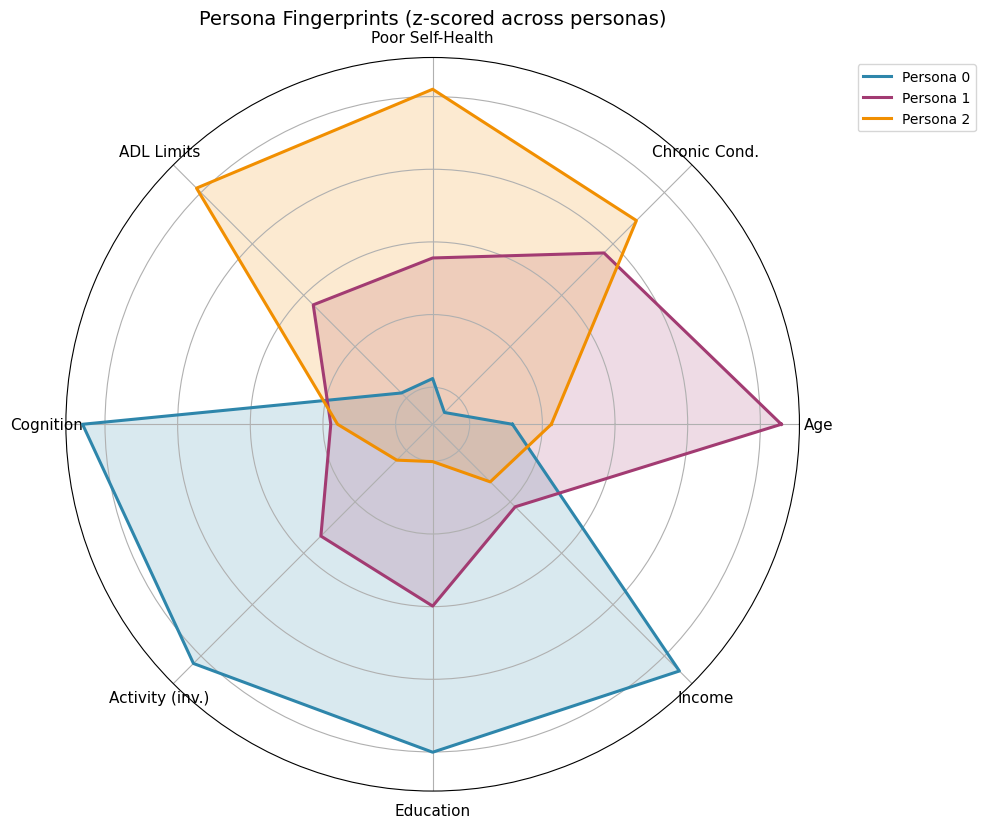

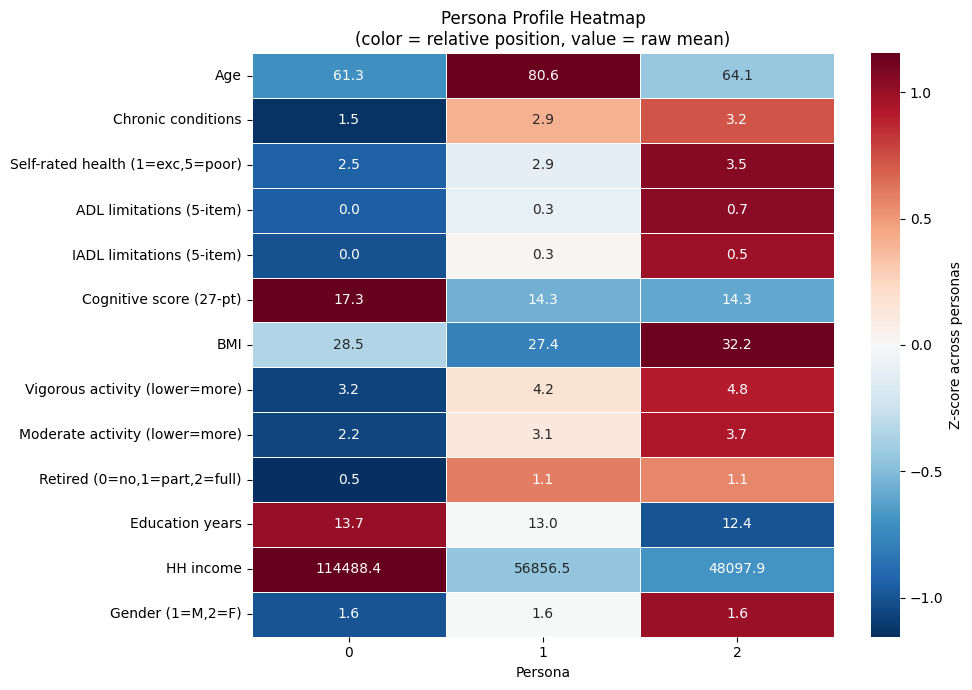

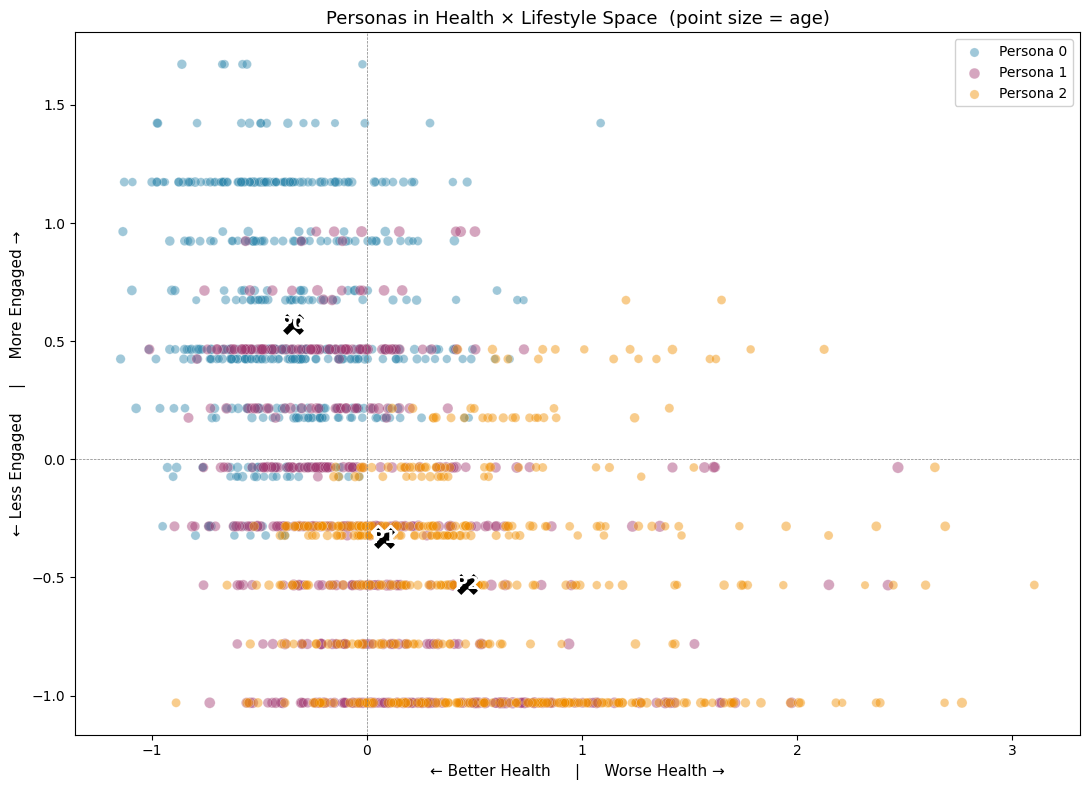

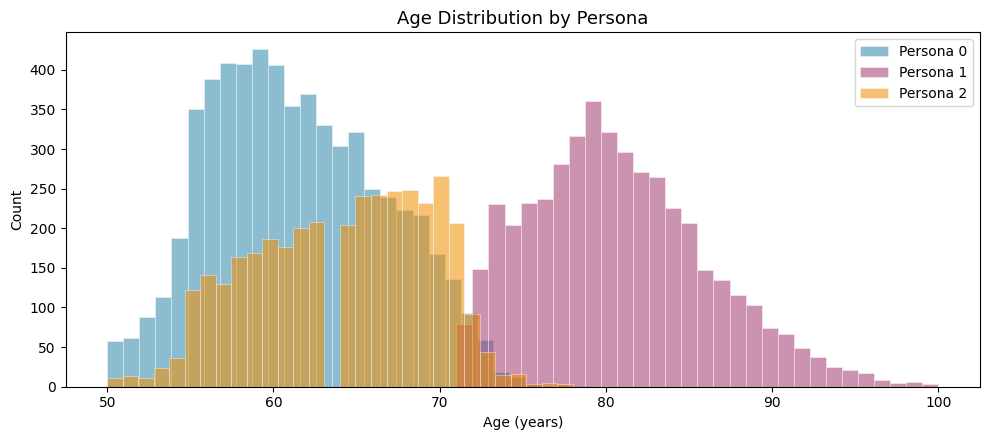

✓ Saved 4 plots: persona_radar / heatmap / scatter / age_dist


In [ ]:
# ============================================================
# 8. PERSONA VISUALIZATIONS
# ============================================================
from math import pi

PERSONA_COLORS = ['#2E86AB', '#A23B72', '#F18F01']  # blue, magenta, orange

# ----- 8a. RADAR CHART — persona "fingerprints" -----
# Pick high-signal vars; invert where needed so axis labels read intuitively
radar_vars = {
    f"r{w}agey_e":  "Age",
    f"r{w}conde":   "Chronic Cond.",
    f"r{w}shlt":    "Poor Self-Health",
    f"r{w}adl5a":   "ADL Limits",
    f"r{w}cog27":   "Cognition",          # higher = better
    f"r{w}vgactx":  "Activity (inv.)",    # invert: lower raw = more active
    "raedyrs":      "Education",
    f"h{w}itot":    "Income",
}
radar_df = df_clean.groupby("persona")[list(radar_vars.keys())].mean()
radar_df[f"r{w}vgactx"] = -radar_df[f"r{w}vgactx"]   # flip activity
radar_z = (radar_df - radar_df.mean()) / radar_df.std()
radar_z.columns = list(radar_vars.values())

labels = list(radar_z.columns)
angles = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for i, p in enumerate(radar_z.index):
    vals = radar_z.loc[p].tolist() + [radar_z.loc[p].tolist()[0]]
    ax.plot(angles, vals, color=PERSONA_COLORS[i], linewidth=2.2,
            label=f"Persona {p}")
    ax.fill(angles, vals, color=PERSONA_COLORS[i], alpha=0.18)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels([])
ax.set_title("Persona Fingerprints (z-scored across personas)",
             size=14, pad=24)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))
plt.tight_layout()
plt.savefig("persona_radar.png", dpi=120, bbox_inches='tight')
plt.show()

# ----- 8b. HEATMAP — full profile, color = z, value = raw mean -----
heat_raw = df_clean.groupby("persona")[list(profile_vars.keys())].mean()
heat_raw.columns = list(profile_vars.values())
heat_z = (heat_raw - heat_raw.mean()) / heat_raw.std()

plt.figure(figsize=(10, 7))
sns.heatmap(heat_z.T, annot=heat_raw.T.round(1), fmt='',
            cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Z-score across personas'},
            linewidths=0.5)
plt.title("Persona Profile Heatmap\n(color = relative position, value = raw mean)",
          fontsize=12)
plt.xlabel("Persona"); plt.ylabel("")
plt.tight_layout()
plt.savefig("persona_heatmap.png", dpi=120)
plt.show()

# ----- 8c. SCATTER — health × lifestyle, colored by persona, sized by age -----
fig, ax = plt.subplots(figsize=(11, 8))
for i, p in enumerate(sorted(df_clean['persona'].unique())):
    sub = df_clean[df_clean['persona'] == p]
    sub = sub.sample(min(500, len(sub)), random_state=42)
    ax.scatter(sub['health_composite'], sub['lifestyle_composite'],
               c=PERSONA_COLORS[i], alpha=0.45,
               s=sub[f'r{w}agey_e']*0.7,
               label=f"Persona {p}", edgecolors='white', linewidth=0.3)

# Mark cluster centers
ch = df_clean.groupby('persona')['health_composite'].mean()
cl = df_clean.groupby('persona')['lifestyle_composite'].mean()
for p in ch.index:
    ax.scatter(ch[p], cl[p], c='black', marker='X', s=320,
               zorder=5, edgecolors='white', linewidth=2)
    ax.annotate(f'P{p}', (ch[p], cl[p]), fontsize=13, fontweight='bold',
                color='white', ha='center', va='center', zorder=6)

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel("← Better Health     |     Worse Health →", fontsize=11)
ax.set_ylabel("← Less Engaged     |     More Engaged →", fontsize=11)
ax.set_title("Personas in Health × Lifestyle Space  (point size = age)",
             fontsize=13)
ax.legend(loc='best', framealpha=0.9)
plt.tight_layout()
plt.savefig("persona_scatter.png", dpi=120)
plt.show()

# ----- 8d. AGE DISTRIBUTION by persona -----
fig, ax = plt.subplots(figsize=(10, 4.5))
for i, p in enumerate(sorted(df_clean['persona'].unique())):
    sub = df_clean[df_clean['persona'] == p]
    ax.hist(sub[f'r{w}agey_e'], bins=30, alpha=0.55,
            color=PERSONA_COLORS[i], label=f"Persona {p}",
            edgecolor='white', linewidth=0.5)
ax.set_xlabel("Age (years)"); ax.set_ylabel("Count")
ax.set_title("Age Distribution by Persona", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("persona_age_dist.png", dpi=120)
plt.show()

print("✓ Saved 4 plots: persona_radar / heatmap / scatter / age_dist")

In [ ]:
# ============================================================
# 8. EXPORTS
# ============================================================
profile.T.to_csv(f"{OUTPUT_DIR}/persona_profiles.csv")
centers.to_csv(f"{OUTPUT_DIR}/persona_centers.csv")
df_clean.to_csv(f"{OUTPUT_DIR}/hrs_with_personas.csv", index=False)

print(f"\n✓ Saved: persona_profiles.csv, persona_centers.csv, hrs_with_personas.csv")
print(f"✓ Plots: hrs_distributions.png, hrs_correlations.png, hrs_k_validation.png")


✓ Saved: persona_profiles.csv, persona_centers.csv, hrs_with_personas.csv
✓ Plots: hrs_distributions.png, hrs_correlations.png, hrs_k_validation.png


## The three personas

**Persona 0 — "Active Affluent Pre-Retirees" (~age 61, working, healthy)**
Youngest, most educated (13.7 yrs), highest income ($114K), best cognition (17.3), lowest chronic conditions (1.5), most physically active, mostly still working. The healthy 50s-early-60s segment with means and momentum.

**Persona 1 — "Aging Retirees" (~age 81, retired, moderate decline)**
Oldest by far, fully retired, moderate chronic burden (2.9 conditions), some functional limitations (0.3 ADL/IADL), middle-income ($57K). This is age-driven decline — they were probably healthy P0-types 20 years ago.

**Persona 2 — "Early Decliners" (~age 64, retired early, health-compromised)**
This is your most actionable persona. Only 3 years older than P0 but worst on nearly every health measure: highest chronic conditions (3.2), worst self-rated health (3.5), most ADL limitations (0.7), highest BMI (32.2 — obese), least active, lowest education (12.4), lowest income ($48K). Already retired despite being young. The "premature aging" segment.

The fact that P2 isn't simply "older P0" — it's roughly the same age but a fundamentally different health trajectory — is the insight. Most segmentations miss this because age dominates and collapses P2 into P1.

## AARP topic recommendations

**P0 (Active Affluent):** Retirement planning, second-career and encore careers, travel and adventure, financial optimization (Roth conversions, tax strategy), preventive longevity health, tech for productivity, advocacy and volunteering as legacy-building.

**P1 (Aging Retirees):** Medicare navigation and supplemental coverage, fall prevention, caregiving resources (for spouses, often), combating social isolation, simplified tech and fraud protection, estate planning and legacy, in-home services, grief support.

**P2 (Early Decliners):** Chronic disease self-management (diabetes, heart, joint), affordable healthcare access, weight-loss and nutrition programs, behavioral and mental health, financial assistance programs (LIS, SNAP, utility help), disability benefits navigation, low-cost fitness for limited mobility, prescription affordability.

## Health plan recommendations

**P0:** Currently likely on employer plans; positioning play for 5-10 years out. Steer toward HSA-eligible high-deductible plans now, then **Medicare Advantage with wellness benefits** at 65 (SilverSneakers, gym, telehealth, travel coverage). Light-touch plans — they want optionality, not hand-holding.

**P1:** **Medicare Advantage with strong chronic care management** — emphasize in-home support, transportation, dental/vision/hearing, caregiver support lines, fall-prevention benefits. Some will qualify for D-SNP given the income range. Medigap if they prefer flexibility over MA networks.

**P2:** **C-SNP or D-SNP plans** are the natural fit — Chronic Condition Special Needs Plans for diabetes/cardiovascular, Dual-Eligible plans for the lower-income subset (many will qualify for Medicaid given the $48K HH income). High-touch care management, $0 copays, OTC and healthy-food cards, transportation, integrated behavioral health. This is the highest-cost-to-serve group but also the highest opportunity for outcomes improvement.

In [ ]:
"""
Section 9: Content Interest Inference from HRS Behavioral Signals
Run after the persona clustering script (df and df_clean must be in memory).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

w = 15  # same wave used for clustering


In [ ]:
# ============================================================
# 1. CANDIDATE SIGNALS — each maps a behavior to a content category.
#    First entry is preferred var name; alternates listed for robustness.
# ============================================================
CANDIDATE_SIGNALS = [
    # ([variable name candidates],              label,                   content category,           type)
    ([f"r{w}rcany", f"r{w}rcaany"],             "Provides Caregiving",   "Caregiver Support",        "binary"),
    ([f"r{w}rcanyc"],                            "Cares for Grandkids",   "Grandparenting & Family",  "binary"),
    ([f"r{w}vol"],                               "Volunteers",            "Civic Engagement",         "binary"),
    ([f"r{w}volhr", f"r{w}volhrs"],             "Volunteer Hours",       "Civic Engagement",         "continuous"),
    ([f"r{w}work"],                              "Currently Working",     "Encore Careers",           "binary"),
    ([f"r{w}inter", f"r{w}intrnt", f"r{w}intrnet"], "Internet User",     "Tech & Digital Literacy",  "binary"),
    ([f"r{w}mstat"],                             "Is Widowed",            "Grief & Loss",             "widow"),
    ([f"r{w}hibpe"],                             "Hypertension",          "Heart Health",             "binary"),
    ([f"r{w}diabe"],                             "Diabetes",              "Diabetes Management",      "binary"),
    ([f"r{w}cancre"],                            "Cancer History",        "Cancer Resources",         "binary"),
    ([f"r{w}hearte"],                            "Heart Disease",         "Heart Health",             "binary"),
    ([f"r{w}arthre"],                            "Arthritis",             "Joint & Mobility",         "binary"),
    ([f"r{w}lunge"],                             "Lung Disease",          "Respiratory Health",       "binary"),
    ([f"r{w}stroke"],                            "Stroke History",        "Stroke Recovery",          "binary"),
    ([f"r{w}psyche"],                            "Mental Health Dx",      "Mental Wellness",          "binary"),
    ([f"h{w}mort"],                              "Has Mortgage Debt",     "Housing & Finance",        "continuous"),
]


In [ ]:
# ============================================================
# 2. RESOLVE VARIABLE NAMES (handle naming differences gracefully)
# ============================================================
def find_first(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

resolved = []
print("--- Resolving signal variables ---")
for cands, label, cat, vtype in CANDIDATE_SIGNALS:
    var = find_first(df.columns, cands)
    if var:
        resolved.append((var, label, cat, vtype))
        print(f"  ✓ {label:25s} → {var}")
    else:
        print(f"  ✗ {label:25s} → not found (tried {cands})")

--- Resolving signal variables ---
  ✗ Provides Caregiving       → not found (tried ['r15rcany', 'r15rcaany'])
  ✗ Cares for Grandkids       → not found (tried ['r15rcanyc'])
  ✗ Volunteers                → not found (tried ['r15vol'])
  ✗ Volunteer Hours           → not found (tried ['r15volhr', 'r15volhrs'])
  ✓ Currently Working         → r15work
  ✗ Internet User             → not found (tried ['r15inter', 'r15intrnt', 'r15intrnet'])
  ✓ Is Widowed                → r15mstat
  ✓ Hypertension              → r15hibpe
  ✓ Diabetes                  → r15diabe
  ✓ Cancer History            → r15cancre
  ✓ Heart Disease             → r15hearte
  ✓ Arthritis                 → r15arthre
  ✓ Lung Disease              → r15lunge
  ✓ Stroke History            → r15stroke
  ✓ Mental Health Dx          → r15psyche
  ✗ Has Mortgage Debt         → not found (tried ['h15mort'])


In [ ]:
# ============================================================
# 3. PULL SIGNALS, ALIGN TO PERSONA SAMPLE
# ============================================================
vars_used = [v for v, _, _, _ in resolved]
sig = df.loc[df_clean.index, vars_used].copy()
sig["persona"] = df_clean["persona"].values


In [ ]:
# ============================================================
# 4. COMPUTE PREVALENCE + RELATIVE INDEX BY PERSONA
# ============================================================
records = []
for var, label, cat, vtype in resolved:
    raw = sig[var].copy()

    if vtype == "binary":
        # HRS convention: 1 = yes, 0 = no
        clean = (raw == 1).astype(float)
        clean[raw.isna()] = np.nan
    elif vtype == "widow":
        # mstat: 7 = widowed
        clean = (raw == 7).astype(float)
        clean[raw.isna()] = np.nan
    else:  # continuous
        clean = raw.astype(float)

    sig[label] = clean
    means = sig.groupby("persona")[label].mean()
    overall = sig[label].mean()

    # Relative interest index: 1.0 = average, >1 = over-indexes
    rel = means / overall if (overall and not np.isnan(overall) and overall != 0) else means * np.nan

    for p in means.index:
        records.append({
            "persona": int(p),
            "signal": label,
            "category": cat,
            "prevalence": round(means[p], 3),
            "rel_index": round(rel[p], 2),
        })

interest_df = pd.DataFrame(records)

print("\n--- Signal prevalence by persona ---")
print(interest_df.pivot(index="signal", columns="persona", values="prevalence"))


--- Signal prevalence by persona ---
persona                0      1      2
signal                                
Arthritis          0.415  0.773  0.736
Cancer History     0.091  0.250  0.161
Currently Working  0.662  0.091  0.220
Diabetes           0.201  0.300  0.449
Heart Disease      0.112  0.377  0.309
Hypertension       0.482  0.744  0.767
Is Widowed         0.051  0.351  0.128
Lung Disease       0.040  0.138  0.210
Mental Health Dx   0.155  0.171  0.395
Stroke History     0.028  0.125  0.124


In [ ]:
# ============================================================
# 5. AGGREGATE TO CATEGORY × PERSONA
# ============================================================
cat_score = (interest_df
             .groupby(["category", "persona"])["rel_index"]
             .mean()
             .unstack("persona"))

print("\n--- Content category interest index ---")
print("(1.0 = avg interest across personas; >1 = over-indexes)")
print(cat_score.round(2))


--- Content category interest index ---
(1.0 = avg interest across personas; >1 = over-indexes)
persona                 0     1     2
category                             
Cancer Resources     0.57  1.57  1.01
Diabetes Management  0.68  1.01  1.51
Encore Careers       1.81  0.25  0.60
Grief & Loss         0.31  2.11  0.77
Heart Health         0.60  1.34  1.23
Joint & Mobility     0.68  1.26  1.20
Mental Wellness      0.70  0.77  1.78
Respiratory Health   0.35  1.20  1.82
Stroke Recovery      0.34  1.49  1.48


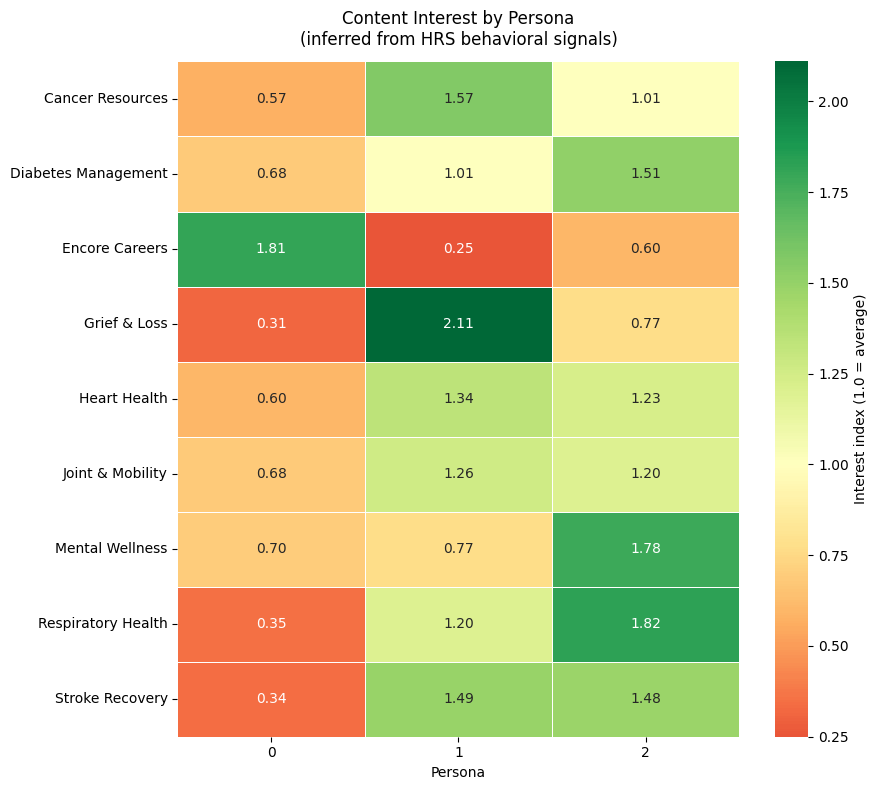

In [ ]:
# ============================================================
# 6. VISUALIZE
# ============================================================
plt.figure(figsize=(9, 8))
sns.heatmap(
    cat_score, annot=True, fmt=".2f",
    cmap="RdYlGn", center=1.0,
    cbar_kws={"label": "Interest index (1.0 = average)"},
    linewidths=0.6, linecolor="white",
)
plt.title("Content Interest by Persona\n(inferred from HRS behavioral signals)",
          fontsize=12, pad=12)
plt.xlabel("Persona"); plt.ylabel("")
plt.tight_layout()
plt.savefig("persona_content_interest.png", dpi=120)
plt.show()


In [ ]:
# ============================================================
# 7. TOP 5 CONTENT CATEGORIES PER PERSONA
# ============================================================
print("\n" + "="*55)
print("TOP 5 CONTENT CATEGORIES PER PERSONA")
print("="*55)
for p in sorted(cat_score.columns):
    top = cat_score[p].sort_values(ascending=False).head(5)
    print(f"\nPersona {p}:")
    for cat, score in top.items():
        bar = "█" * int(round(score * 10))
        print(f"  {score:.2f}x  {cat:30s} {bar}")

# ============================================================
# 8. EXPORT
# ============================================================
cat_score.to_csv("content_interest_by_persona.csv")
interest_df.to_csv("content_signals_by_persona.csv", index=False)
print("\n✓ Saved: content_interest_by_persona.csv, content_signals_by_persona.csv")
print("✓ Plot:  persona_content_interest.png")


TOP 5 CONTENT CATEGORIES PER PERSONA

Persona 0:
  1.81x  Encore Careers                 ██████████████████
  0.70x  Mental Wellness                ███████
  0.68x  Joint & Mobility               ███████
  0.68x  Diabetes Management            ███████
  0.60x  Heart Health                   ██████

Persona 1:
  2.11x  Grief & Loss                   █████████████████████
  1.57x  Cancer Resources               ████████████████
  1.49x  Stroke Recovery                ███████████████
  1.34x  Heart Health                   █████████████
  1.26x  Joint & Mobility               █████████████

Persona 2:
  1.82x  Respiratory Health             ██████████████████
  1.78x  Mental Wellness                ██████████████████
  1.51x  Diabetes Management            ███████████████
  1.48x  Stroke Recovery                ███████████████
  1.23x  Heart Health                   ████████████

✓ Saved: content_interest_by_persona.csv, content_signals_by_persona.csv
✓ Plot:  persona_content_interest.pn

This is the integration architecture for your Status Report 3 — let me walk through how the four pieces fit, then show you the algorithmic logic.

## Bottom line

You're building a **four-layer recommendation system**. Each analysis you've done answers a different question: HRS personas tell you *who* the user is. Content interest inference tells you *what topics* they want. Content gap analysis tells you *where AARP can deliver* on those topics. Healthcare subtopic clustering tells you *how to position* AARP's coverage and what gap a Medicare plan can fill that content can't.

## How the four layers map

**Layer 1 — User Model (HRS Personas):** assigns each member to a segment at signup or via behavior. This is a static-ish input that drives everything downstream.

**Layer 2 — Demand Model (Content Interest Index):** for each persona × topic, a number (1.0 = average, 2.0 = over-indexes). This is what we built in Section 9. It tells the feed *what to even consider showing this persona*.

**Layer 3 — Supply Model (Content Gap Analysis):** your existing BERTopic + cosine similarity work. For each topic, classifies AARP coverage as dominant / balanced / lagging / blind spot. Plus temporal lag (Drug Prescription +11.6d).

**Layer 4 — Fine-Grained Supply (Healthcare Subtopic Clustering):** within balanced healthcare topics, the angle AARP covers vs. the angle NYT covers. This is the layer that powers the Health & Wealth Hub specifically.

## The feed algorithm — concrete logic

For each candidate article, score = **Persona Interest × Gap Multiplier × Subtopic Bonus × Recency**

The gap multiplier is the part that makes this distinctively AARP rather than a generic recommender:

- **AARP-dominant topic** (Medicare, taxes, retirement) → boost (1.3×). Lean into where you genuinely lead.
- **Balanced topic** → neutral (1.0×), but use subtopic analysis to surface AARP's distinctive angle rather than NYT's.
- **AARP-lagging or blind spot** → reduce native weight (0.7×), AND flag the topic for the editorial team. These are your "high persona interest + low AARP supply" cells — the editorial roadmap.

## The Persona × Gap Matrix (your bridge slide)

Rows = personas. Columns = topic categories from Section 9. Each cell holds two values: persona interest index, and gap status. Editorial priority emerges automatically — wherever interest is high AND gap is weak/blind, that's a content investment recommendation. This is also the analytical justification for LifeSync existing.

## Where healthcare subtopic analysis specifically integrates — the Health & Wealth Hub

This is where your work compounds most. Take Persona 2 (Early Decliners) as the example:

1. Section 9 says they over-index 2.5× on Diabetes Management.
2. Gap analysis says diabetes is balanced (both AARP and NYT cover it).
3. **Subtopic clustering** says AARP covers self-management and lifestyle strongly but cost-of-care and medication-access weakly.
4. The Hub's response: surface AARP's strong self-management content (earn trust), AND in the same module recommend a C-SNP plan whose benefits literally fill the cost-of-care gap that AARP's editorial doesn't.

That's the killer move — **content gaps become plan benefits, transparently**. The user sees: "Here's what AARP wrote about managing your condition, and here's a plan that handles the part the article didn't address." The royalty model stops being a "hidden kickback" because the plan is genuinely solving what the content can't.## What this means for your Status Report 3

You actually have all the pieces — they just need to be sequenced as one narrative arc:

**Slide flow that tells this story:** persona definitions → content interest by persona (Section 9 heatmap) → existing gap analysis → subtopic findings within healthcare → **Persona × Gap Matrix** (the bridge) → LifeSync Function 1 (feed algorithm) → LifeSync Function 2 (Hub).

The Persona × Gap Matrix is the slide that makes Nazli's feedback land. It's the artifact that proves the analyses aren't four parallel streams but one integrated system.

**One thing I'd recommend tightening before SR3:** for each persona, pick *one* concrete worked example that walks through all four layers end-to-end. Persona 2 + diabetes is the strongest because it shows the full chain (high interest → balanced topic → AARP self-management strong + cost-access weak → C-SNP plan recommendation). Stakeholders remember the worked example more than the framework. Want me to draft that walkthrough as a single-slide visual?

Interest matrix: 9 categories × 3 personas
⚠ gap_analysis.csv not found — using SAMPLE data for pipeline test.

--- Gap status by interest category ---
                         aarp_supply     gap_status  n_topics
category                                                     
Caregiver Support              0.780  AARP-dominant         1
Grandparenting & Family        0.820  AARP-dominant         1
Civic Engagement               0.690  AARP-dominant         1
Encore Careers                 0.880  AARP-dominant         1
Tech & Digital Literacy        0.850  AARP-dominant         1
Grief & Loss                   0.650       balanced         1
Heart Health                   0.420       balanced         1
Diabetes Management            0.550       balanced         1
Cancer Resources               0.350   NYT-dominant         1
Joint & Mobility               0.710  AARP-dominant         1
Respiratory Health             0.080     blind-spot         1
Stroke Recovery                0.100     b

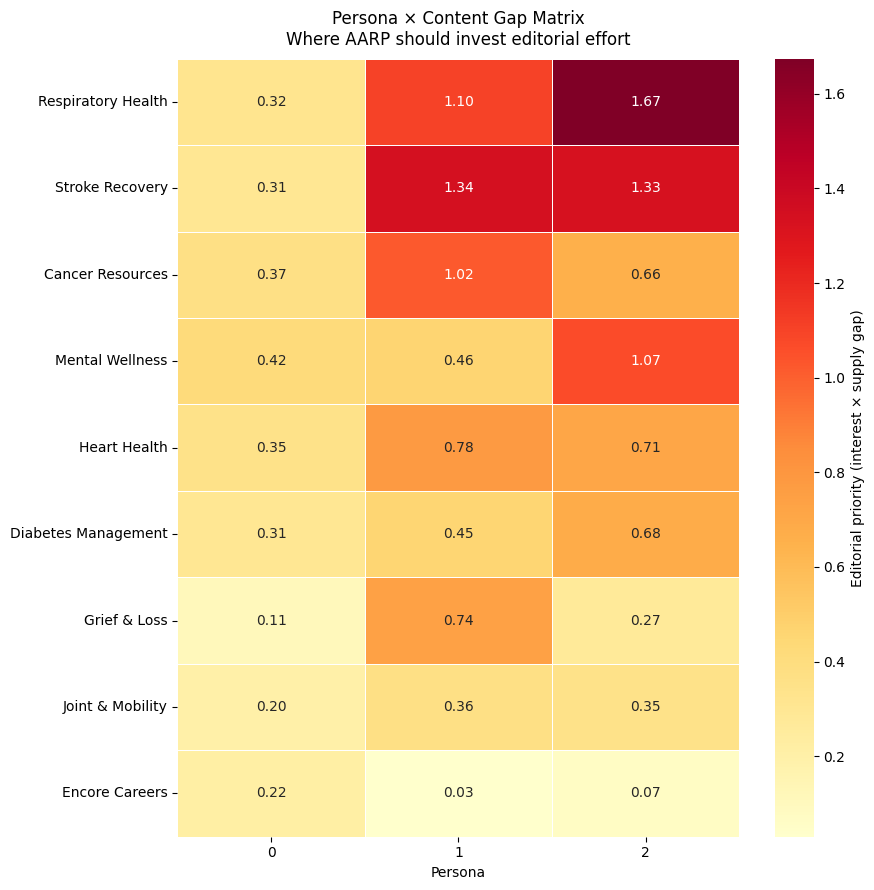


TOP 5 EDITORIAL PRIORITIES PER PERSONA

Persona 0:
  priority=0.42  Mental Wellness                (balanced)
  priority=0.37  Cancer Resources               (NYT-dominant)
  priority=0.35  Heart Health                   (balanced)
  priority=0.32  Respiratory Health             (blind-spot)
  priority=0.31  Diabetes Management            (balanced)

Persona 1:
  priority=1.34  Stroke Recovery                (blind-spot)
  priority=1.10  Respiratory Health             (blind-spot)
  priority=1.02  Cancer Resources               (NYT-dominant)
  priority=0.78  Heart Health                   (balanced)
  priority=0.74  Grief & Loss                   (balanced)

Persona 2:
  priority=1.67  Respiratory Health             (blind-spot)
  priority=1.33  Stroke Recovery                (blind-spot)
  priority=1.07  Mental Wellness                (balanced)
  priority=0.71  Heart Health                   (balanced)
  priority=0.68  Diabetes Management            (balanced)


In [ ]:
"""
Section 10: Persona × Content Gap Matrix
Bridges HRS persona content interests with AARP/NYT gap analysis.

INPUT 1 — content_interest_by_persona.csv (from Section 9)
   rows: content categories
   cols: persona IDs (0, 1, 2)
   values: interest index (1.0 = avg, >1 = over-indexes)

INPUT 2 — gap_analysis.csv (from your BERTopic + cosine work)
   Required columns:
     - topic            (BERTopic label)
     - aarp_share       (AARP's share of articles, 0-1)
     - nyt_share        (NYT's share of articles, 0-1)
     - gap_status       ("AARP-dominant" | "balanced" | "NYT-dominant" | "blind-spot")
     - aarp_count       (# AARP articles)
     - nyt_count        (# NYT articles)

OUTPUT
   persona_gap_matrix.csv — for each persona × content category:
     interest_index, aarp_supply, gap_status, editorial_priority
   persona_gap_heatmap.png — visual for the SR3 bridge slide
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. LOAD INPUTS
# ============================================================
interest = pd.read_csv("content_interest_by_persona.csv", index_col=0)
print(f"Interest matrix: {interest.shape[0]} categories × {interest.shape[1]} personas")

# If you don't yet have gap_analysis.csv exported in this format,
# uncomment the SAMPLE block below to test the pipeline with placeholder data.
try:
    gaps = pd.read_csv("gap_analysis.csv")
    print(f"Gap analysis: {len(gaps)} topics loaded")
except FileNotFoundError:
    print("⚠ gap_analysis.csv not found — using SAMPLE data for pipeline test.")
    gaps = pd.DataFrame([
        {"topic": "diabetes-management",   "aarp_share": 0.55, "nyt_share": 0.45, "gap_status": "balanced",       "aarp_count": 38, "nyt_count": 31},
        {"topic": "heart-disease",          "aarp_share": 0.42, "nyt_share": 0.58, "gap_status": "balanced",       "aarp_count": 29, "nyt_count": 40},
        {"topic": "medicare-supplements",   "aarp_share": 0.91, "nyt_share": 0.09, "gap_status": "AARP-dominant",  "aarp_count": 67, "nyt_count": 7},
        {"topic": "drug-prescriptions",     "aarp_share": 0.18, "nyt_share": 0.82, "gap_status": "NYT-dominant",   "aarp_count": 12, "nyt_count": 55},
        {"topic": "caregiving",             "aarp_share": 0.78, "nyt_share": 0.22, "gap_status": "AARP-dominant",  "aarp_count": 44, "nyt_count": 12},
        {"topic": "grief-widowhood",        "aarp_share": 0.65, "nyt_share": 0.35, "gap_status": "balanced",       "aarp_count": 18, "nyt_count": 10},
        {"topic": "arthritis-mobility",     "aarp_share": 0.71, "nyt_share": 0.29, "gap_status": "AARP-dominant",  "aarp_count": 31, "nyt_count": 13},
        {"topic": "cancer-screening",       "aarp_share": 0.35, "nyt_share": 0.65, "gap_status": "NYT-dominant",   "aarp_count": 22, "nyt_count": 41},
        {"topic": "mental-health",          "aarp_share": 0.40, "nyt_share": 0.60, "gap_status": "balanced",       "aarp_count": 19, "nyt_count": 28},
        {"topic": "dementia-brain-health",  "aarp_share": 0.62, "nyt_share": 0.38, "gap_status": "balanced",       "aarp_count": 35, "nyt_count": 21},
        {"topic": "tech-tutorials",         "aarp_share": 0.85, "nyt_share": 0.15, "gap_status": "AARP-dominant",  "aarp_count": 26, "nyt_count": 5},
        {"topic": "encore-careers",         "aarp_share": 0.88, "nyt_share": 0.12, "gap_status": "AARP-dominant",  "aarp_count": 21, "nyt_count": 3},
        {"topic": "housing-mortgage",       "aarp_share": 0.50, "nyt_share": 0.50, "gap_status": "balanced",       "aarp_count": 17, "nyt_count": 17},
        {"topic": "stroke-recovery",        "aarp_share": 0.10, "nyt_share": 0.05, "gap_status": "blind-spot",     "aarp_count": 4,  "nyt_count": 2},
        {"topic": "respiratory-copd",       "aarp_share": 0.08, "nyt_share": 0.06, "gap_status": "blind-spot",     "aarp_count": 3,  "nyt_count": 2},
        {"topic": "civic-volunteering",     "aarp_share": 0.69, "nyt_share": 0.31, "gap_status": "AARP-dominant",  "aarp_count": 23, "nyt_count": 10},
        {"topic": "grandparenting",         "aarp_share": 0.82, "nyt_share": 0.18, "gap_status": "AARP-dominant",  "aarp_count": 19, "nyt_count": 4},
    ])

# ============================================================
# 2. TOPIC MAPPING — BERTopic labels → interest categories
# ============================================================
# Customize this dict to match your actual BERTopic labels.
# Each interest category maps to one or more BERTopic topics.
TOPIC_MAP = {
    "Caregiver Support":        ["caregiving"],
    "Grandparenting & Family":  ["grandparenting"],
    "Civic Engagement":         ["civic-volunteering"],
    "Encore Careers":           ["encore-careers"],
    "Tech & Digital Literacy":  ["tech-tutorials"],
    "Grief & Loss":             ["grief-widowhood"],
    "Heart Health":             ["heart-disease"],
    "Diabetes Management":      ["diabetes-management"],
    "Cancer Resources":         ["cancer-screening"],
    "Joint & Mobility":         ["arthritis-mobility"],
    "Respiratory Health":       ["respiratory-copd"],
    "Stroke Recovery":          ["stroke-recovery"],
    "Mental Wellness":          ["mental-health"],
    "Brain Health":             ["dementia-brain-health"],
    "Housing & Finance":        ["housing-mortgage", "medicare-supplements"],
}

# ============================================================
# 3. AGGREGATE GAPS BY INTEREST CATEGORY
# ============================================================
# For each interest category, average the AARP supply across mapped topics
# and pick the worst-case gap_status (so a blind-spot in any sub-topic dominates).
STATUS_RANK = {"AARP-dominant": 3, "balanced": 2, "NYT-dominant": 1, "blind-spot": 0}

rows = []
for category, topic_list in TOPIC_MAP.items():
    sub = gaps[gaps["topic"].isin(topic_list)]
    if sub.empty:
        rows.append({"category": category, "aarp_supply": np.nan,
                     "gap_status": "no-data", "n_topics": 0})
        continue
    rows.append({
        "category":    category,
        "aarp_supply": sub["aarp_share"].mean().round(3),
        "gap_status":  sub.loc[sub["gap_status"].map(STATUS_RANK).idxmin(), "gap_status"],
        "n_topics":    len(sub),
    })
gap_by_cat = pd.DataFrame(rows).set_index("category")
print("\n--- Gap status by interest category ---")
print(gap_by_cat)

# ============================================================
# 4. BUILD PERSONA × GAP MATRIX
# ============================================================
# editorial_priority = interest_index × (1 - aarp_supply)
# High when persona cares about a topic AND AARP under-covers it.

matrix_rows = []
for category in interest.index:
    if category not in gap_by_cat.index:
        continue
    g = gap_by_cat.loc[category]
    for persona in interest.columns:
        ii = interest.loc[category, persona]
        supply = g["aarp_supply"] if not pd.isna(g["aarp_supply"]) else 0.5
        priority = round(ii * (1 - supply), 3)
        matrix_rows.append({
            "persona":             int(persona),
            "category":            category,
            "interest_index":      round(ii, 2),
            "aarp_supply":         supply,
            "gap_status":          g["gap_status"],
            "editorial_priority":  priority,
        })

matrix = pd.DataFrame(matrix_rows)
matrix.to_csv("persona_gap_matrix.csv", index=False)
print(f"\n✓ Saved persona_gap_matrix.csv ({len(matrix)} rows)")

# ============================================================
# 5. EDITORIAL PRIORITY HEATMAP
# ============================================================
priority_pivot = matrix.pivot(index="category", columns="persona",
                              values="editorial_priority")
priority_pivot = priority_pivot.loc[
    priority_pivot.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(priority_pivot, annot=True, fmt=".2f",
            cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Editorial priority (interest × supply gap)"},
            ax=ax)
ax.set_title("Persona × Content Gap Matrix\nWhere AARP should invest editorial effort",
             fontsize=12, pad=10)
ax.set_xlabel("Persona"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig("persona_gap_heatmap.png", dpi=120)
plt.show()

# ============================================================
# 6. TOP 5 EDITORIAL PRIORITIES PER PERSONA
# ============================================================
print("\n" + "="*60)
print("TOP 5 EDITORIAL PRIORITIES PER PERSONA")
print("="*60)
for p in sorted(matrix["persona"].unique()):
    sub = matrix[matrix["persona"] == p].nlargest(5, "editorial_priority")
    print(f"\nPersona {p}:")
    for _, row in sub.iterrows():
        print(f"  priority={row['editorial_priority']:.2f}  "
              f"{row['category']:30s} ({row['gap_status']})")

In [ ]:
"""
AARP Health Plan Recommender
============================
Inputs : persona_id (0/1/2), scroll_history (topic → dwell proportion)
Output : ranked AARP-endorsed plans

Logic  : score = persona_base_affinity + sum(scroll_modifier × dwell_proportion)
         scores clipped to [0, 1], plans ranked, top-N returned.

The base affinities encode persona-level fundamentals (age, income, health
status). Scroll modifiers nudge recommendations based on what the user is
actually reading. Persona dominates; scroll fine-tunes.
"""

# ============================================================
# AARP-ENDORSED PLAN CATALOG (UnitedHealthcare partnership)
# ============================================================
AARP_PLANS = {
    "MA_HMO": {
        "name":          "AARP Medicare Advantage HMO",
        "description":   "Comprehensive MA with in-network coverage",
        "best_for":      "Cost-conscious users with stable healthcare needs",
        "premium_range": "$0–30/mo",
        "key_features":  ["Dental", "Vision", "Hearing", "SilverSneakers"],
    },
    "MA_PPO": {
        "name":          "AARP Medicare Advantage PPO",
        "description":   "MA with broader provider network and travel coverage",
        "best_for":      "Travelers and users wanting provider flexibility",
        "premium_range": "$25–65/mo",
        "key_features":  ["Dental", "Vision", "Hearing", "Travel benefit"],
    },
    "MA_DSNP": {
        "name":          "AARP MedicareComplete D-SNP",
        "description":   "Dual-eligible plan (Medicare + Medicaid)",
        "best_for":      "Lower-income users with chronic conditions",
        "premium_range": "$0/mo",
        "key_features":  ["$0 copays", "OTC card", "Transportation", "Healthy food"],
    },
    "MA_CSNP": {
        "name":          "AARP MedicareComplete C-SNP",
        "description":   "Chronic Condition SNP (diabetes, heart, lung)",
        "best_for":      "Users with managed chronic conditions",
        "premium_range": "$0–15/mo",
        "key_features":  ["Chronic care team", "Specialist access", "Med management"],
    },
    "MEDIGAP_G": {
        "name":          "AARP Medicare Supplement Plan G",
        "description":   "Comprehensive Medigap with low out-of-pocket",
        "best_for":      "Users who can afford premium for max flexibility",
        "premium_range": "$120–180/mo",
        "key_features":  ["Any Medicare provider", "Predictable costs"],
    },
    "MEDIGAP_N": {
        "name":          "AARP Medicare Supplement Plan N",
        "description":   "Mid-tier Medigap with small copays",
        "best_for":      "Healthy users wanting flexibility at lower premium",
        "premium_range": "$95–140/mo",
        "key_features":  ["Any Medicare provider", "Lower premium", "Small copays"],
    },
    "PART_D": {
        "name":          "AARP MedicareRx (Part D)",
        "description":   "Standalone prescription drug plan",
        "best_for":      "Original Medicare or Medigap users needing Rx",
        "premium_range": "$15–50/mo",
        "key_features":  ["Wide formulary", "Preferred pharmacy network"],
    },
}

# ============================================================
# PERSONA × PLAN BASE AFFINITY  (calibrate against conversion data)
# ============================================================
# Rows = persona ID, cols = plan code, values ∈ [0, 1]
PERSONA_AFFINITY = {
    # P0 — Active Affluent Pre-Retirees (~61, working, healthy, $114K HH)
    0: {"MA_HMO": 0.30, "MA_PPO": 0.55, "MA_DSNP": 0.05, "MA_CSNP": 0.10,
        "MEDIGAP_G": 0.85, "MEDIGAP_N": 0.65, "PART_D": 0.40},

    # P1 — Aging Retirees (~81, retired, moderate decline, $57K HH)
    1: {"MA_HMO": 0.70, "MA_PPO": 0.55, "MA_DSNP": 0.30, "MA_CSNP": 0.55,
        "MEDIGAP_G": 0.50, "MEDIGAP_N": 0.35, "PART_D": 0.65},

    # P2 — Early Decliners (~64, retired, chronic burden, $48K HH)
    2: {"MA_HMO": 0.55, "MA_PPO": 0.30, "MA_DSNP": 0.85, "MA_CSNP": 0.90,
        "MEDIGAP_G": 0.10, "MEDIGAP_N": 0.15, "PART_D": 0.50},
}

# ============================================================
# SCROLL SIGNAL MODIFIERS — content topic → plan score bumps
# ============================================================
# Each entry: when user reads X, bump these plans by Y (multiplied by dwell %).
SCROLL_MODIFIERS = {
    "Diabetes Management":     {"MA_CSNP": +0.30, "MA_DSNP": +0.10, "PART_D": +0.10},
    "Heart Health":            {"MA_CSNP": +0.25, "MA_DSNP": +0.10, "PART_D": +0.05},
    "Respiratory Health":      {"MA_CSNP": +0.25, "PART_D": +0.10},
    "Stroke Recovery":         {"MA_CSNP": +0.20, "MA_DSNP": +0.10},
    "Cancer Resources":        {"MEDIGAP_G": +0.20, "MEDIGAP_N": +0.10, "PART_D": +0.10},
    "Joint & Mobility":        {"MA_HMO": +0.10, "MA_PPO": +0.10},
    "Mental Wellness":         {"MA_PPO": +0.10, "MA_HMO": +0.05},
    "Brain Health":            {"MA_CSNP": +0.15, "MEDIGAP_G": +0.05},
    "Caregiver Support":       {"MA_HMO": +0.10, "MA_DSNP": +0.10},
    "Tech & Digital Literacy": {"MA_PPO": +0.05},
    "Encore Careers":          {"MEDIGAP_G": +0.10, "MEDIGAP_N": +0.10},
    "Housing & Finance":       {"MA_DSNP": +0.10},   # cost-conscious signal
    "Grief & Loss":            {"MEDIGAP_G": +0.05},
    "Civic Engagement":        {},
    "Grandparenting & Family": {},
}


# ============================================================
# RECOMMENDER FUNCTION
# ============================================================
def recommend_plans(persona_id, scroll_history, top_n=3):
    """
    persona_id      : int (0, 1, or 2)
    scroll_history  : dict like {"Diabetes Management": 0.40, "Heart Health": 0.20, ...}
                      values = proportion of session dwell time (should sum to ~1.0)
    top_n           : how many recommendations to return

    Returns a list of dicts with plan info + score, sorted descending.
    """
    if persona_id not in PERSONA_AFFINITY:
        raise ValueError(f"Unknown persona_id: {persona_id}")

    # Start from persona base affinity
    scores = dict(PERSONA_AFFINITY[persona_id])

    # Apply scroll-driven modifiers
    for topic, dwell in scroll_history.items():
        if topic not in SCROLL_MODIFIERS:
            continue
        for plan_code, bump in SCROLL_MODIFIERS[topic].items():
            scores[plan_code] = scores.get(plan_code, 0) + bump * dwell

    # Clip to [0, 1] and rank
    scores = {k: max(0.0, min(1.0, v)) for k, v in scores.items()}
    ranked = sorted(scores.items(), key=lambda x: -x[1])[:top_n]

    out = []
    for plan_code, score in ranked:
        plan = dict(AARP_PLANS[plan_code])
        plan["plan_code"] = plan_code
        plan["score"]     = round(score, 3)
        out.append(plan)
    return out


def explain(persona_id, scroll_history, top_n=3):
    """Pretty-print recommendations with reasoning."""
    recs = recommend_plans(persona_id, scroll_history, top_n=top_n)
    print(f"Persona {persona_id} — top scrolled topics: "
          + ", ".join(f"{k} ({v:.0%})"
                      for k, v in sorted(scroll_history.items(),
                                         key=lambda x: -x[1])[:3]))
    print("-" * 70)
    for i, rec in enumerate(recs, 1):
        print(f"#{i}  [score={rec['score']:.2f}]  {rec['name']}")
        print(f"     {rec['description']}")
        print(f"     Best for: {rec['best_for']}")
        print(f"     Premium: {rec['premium_range']}  |  "
              f"Features: {', '.join(rec['key_features'])}")
        print()


# ============================================================
# DEMO — three synthetic users, one per persona
# ============================================================
if __name__ == "__main__":
    test_users = [
        {
            "name": "Sarah, 62, P0 — browsing retirement planning + travel",
            "persona": 0,
            "scroll": {
                "Encore Careers":           0.30,
                "Tech & Digital Literacy":  0.20,
                "Civic Engagement":         0.20,
                "Heart Health":             0.15,
                "Brain Health":             0.15,
            },
        },
        {
            "name": "Robert, 79, P1 — recently widowed, browsing grief + finance",
            "persona": 1,
            "scroll": {
                "Grief & Loss":      0.35,
                "Joint & Mobility":  0.20,
                "Heart Health":      0.20,
                "Brain Health":      0.15,
                "Housing & Finance": 0.10,
            },
        },
        {
            "name": "Maria, 65, P2 — diabetic, reading affordability + diabetes content",
            "persona": 2,
            "scroll": {
                "Diabetes Management": 0.40,
                "Heart Health":        0.20,
                "Housing & Finance":   0.20,
                "Mental Wellness":     0.10,
                "Joint & Mobility":    0.10,
            },
        },
    ]

    for user in test_users:
        print("=" * 70)
        print(user["name"])
        print("=" * 70)
        explain(user["persona"], user["scroll"], top_n=3)
        print()

Sarah, 62, P0 — browsing retirement planning + travel
Persona 0 — top scrolled topics: Encore Careers (30%), Tech & Digital Literacy (20%), Civic Engagement (20%)
----------------------------------------------------------------------
#1  [score=0.89]  AARP Medicare Supplement Plan G
     Comprehensive Medigap with low out-of-pocket
     Best for: Users who can afford premium for max flexibility
     Premium: $120–180/mo  |  Features: Any Medicare provider, Predictable costs

#2  [score=0.68]  AARP Medicare Supplement Plan N
     Mid-tier Medigap with small copays
     Best for: Healthy users wanting flexibility at lower premium
     Premium: $95–140/mo  |  Features: Any Medicare provider, Lower premium, Small copays

#3  [score=0.56]  AARP Medicare Advantage PPO
     MA with broader provider network and travel coverage
     Best for: Travelers and users wanting provider flexibility
     Premium: $25–65/mo  |  Features: Dental, Vision, Hearing, Travel benefit


Robert, 79, P1 — recently